# LDCast autoencoder temporal-position diagnostic

This notebook reproduces the LDCast autoencoder diagnostic used in the thesis.

The diagnostic was motivated by the regular four-step oscillation observed in
the full-data LDCast verification curves. The VAE compresses the temporal
dimension: one latent temporal step is decoded into four consecutive
precipitation fields. Reconstruction error is therefore examined separately for
temporal positions \(0,1,2,3\) within each four-frame block.

The summary plots use the final diagnostic values computed over all 1,460 cases
of the 2021 six-hourly test subset. The last section runs one full-domain VAE
reconstruction directly in the Jupyter session so that the original and
reconstructed fields can be inspected without loading a previously exported
`.npz` file.

## Imports and output directory

In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

MLCAST_ROOT = Path("/data/brussel/114/vsc11442/code/mlcast-ldcast")

FIG_DIR = (
    MLCAST_ROOT
    / "results"
    / "evaluation"
    / "test_2021_6hourly"
    / "figures_results"
)

FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Figures will be saved to:")
print(FIG_DIR)

Figures will be saved to:
/data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results


## Final diagnostic summary

Bias is defined as reconstructed rain rate minus observed rain rate.
MAE is the mean absolute reconstruction error.

The values are those reported in the final thesis table for the 10% and
full-data autoencoders.

In [2]:

diagnostic = pd.DataFrame(
    [
        {"Autoencoder": "10%",  "Position": 0, "Bias": -0.0006, "MAE": 0.0362},
        {"Autoencoder": "10%",  "Position": 1, "Bias": -0.0132, "MAE": 0.0242},
        {"Autoencoder": "10%",  "Position": 2, "Bias":  0.0007, "MAE": 0.0361},
        {"Autoencoder": "10%",  "Position": 3, "Bias": -0.0125, "MAE": 0.0241},
        {"Autoencoder": "Full", "Position": 0, "Bias": -0.0085, "MAE": 0.0326},
        {"Autoencoder": "Full", "Position": 1, "Bias":  0.0342, "MAE": 0.0600},
        {"Autoencoder": "Full", "Position": 2, "Bias": -0.0092, "MAE": 0.0329},
        {"Autoencoder": "Full", "Position": 3, "Bias":  0.0368, "MAE": 0.0617},
    ]
)

display(diagnostic)

,Autoencoder,Position,Bias,MAE
0,10%,0,-0.0006,0.0362
1,10%,1,-0.0132,0.0242
2,10%,2,0.0007,0.0361
3,10%,3,-0.0125,0.0241
4,Full,0,-0.0085,0.0326
5,Full,1,0.0342,0.0600
6,Full,2,-0.0092,0.0329
7,Full,3,0.0368,0.0617


## VAE temporal decoding structure

The schematic below illustrates the temporal structure relevant to the
diagnostic: one latent temporal step is expanded into four consecutive decoded
precipitation fields. These are the four temporal positions used in the
reconstruction analysis.

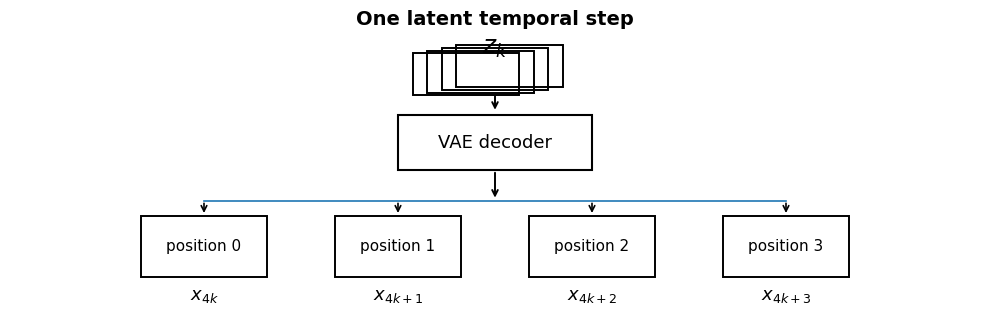

Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/ldcast_vae_temporal_structure.png


In [3]:

fig, ax = plt.subplots(figsize=(10, 3.4))

ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

# Latent representation
latent_x = 5.0
latent_y = 3.2

ax.text(
    latent_x,
    latent_y + 0.35,
    r"$z_k$",
    ha="center",
    va="center",
    fontsize=18,
)

for offset in [-0.30, -0.15, 0.0, 0.15]:
    rect = plt.Rectangle(
        (latent_x - 0.55 + offset, latent_y - 0.20 + offset * 0.25),
        1.1,
        0.55,
        fill=False,
        linewidth=1.4,
    )
    ax.add_patch(rect)

# Decoder box
decoder = plt.Rectangle(
    (4.0, 1.95),
    2.0,
    0.72,
    fill=False,
    linewidth=1.5,
)
ax.add_patch(decoder)

ax.text(
    5.0,
    2.31,
    "VAE decoder",
    ha="center",
    va="center",
    fontsize=13,
)

ax.annotate(
    "",
    xy=(5.0, 2.70),
    xytext=(5.0, 2.95),
    arrowprops=dict(arrowstyle="->", linewidth=1.4),
)

# Four decoded temporal positions
frame_centres = [2.0, 4.0, 6.0, 8.0]

for pos, x in enumerate(frame_centres):
    rect = plt.Rectangle(
        (x - 0.65, 0.55),
        1.3,
        0.8,
        fill=False,
        linewidth=1.4,
    )
    ax.add_patch(rect)

    ax.text(
        x,
        0.95,
        f"position {pos}",
        ha="center",
        va="center",
        fontsize=11,
    )

    ax.text(
        x,
        0.30,
        rf"$x_{{4k+{pos}}}$" if pos > 0 else r"$x_{4k}$",
        ha="center",
        va="center",
        fontsize=13,
    )

# Decoder to four outputs
ax.annotate(
    "",
    xy=(5.0, 1.55),
    xytext=(5.0, 1.95),
    arrowprops=dict(arrowstyle="->", linewidth=1.4),
)

ax.plot([2.0, 8.0], [1.55, 1.55], linewidth=1.2)

for x in frame_centres:
    ax.annotate(
        "",
        xy=(x, 1.35),
        xytext=(x, 1.55),
        arrowprops=dict(arrowstyle="->", linewidth=1.2),
    )

ax.text(
    5.0,
    3.92,
    "One latent temporal step",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout()

output_path = FIG_DIR / "ldcast_vae_temporal_structure.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

## Reconstruction error by temporal position

The next figure shows both diagnostic quantities used in the thesis:

- **MAE:** lower is better;
- **bias:** values close to zero are preferable, while the sign indicates the
  direction of the reconstruction bias.

For the full-data autoencoder, positions 1 and 3 have substantially larger MAE
and positive bias compared with positions 0 and 2. The 10% autoencoder also
depends on temporal position, but its pattern is different.

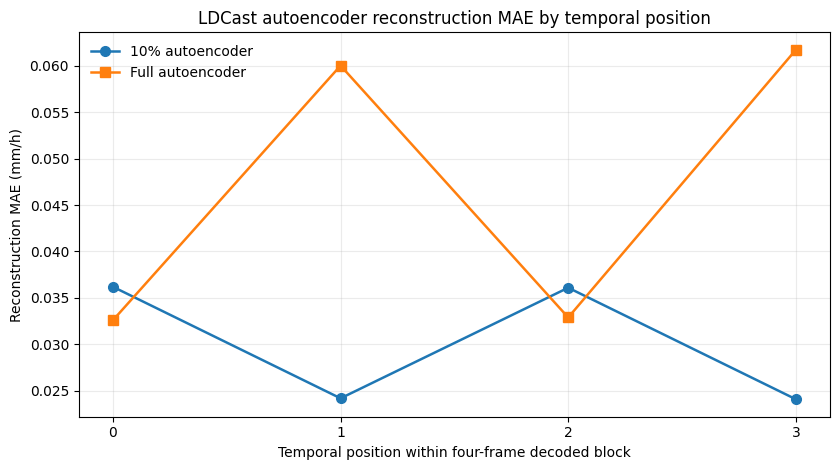

Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/ldcast_ae_mae_by_temporal_position.png


In [4]:

fig, ax = plt.subplots(figsize=(8.5, 4.8))

for split, marker in [
    ("10%", "o"),
    ("Full", "s"),
]:
    subset = diagnostic[diagnostic["Autoencoder"] == split]

    ax.plot(
        subset["Position"],
        subset["MAE"],
        marker=marker,
        linewidth=1.8,
        markersize=7,
        label=f"{split} autoencoder",
    )

ax.set_xticks([0, 1, 2, 3])
ax.set_xlabel("Temporal position within four-frame decoded block")
ax.set_ylabel("Reconstruction MAE (mm/h)")
ax.set_title("LDCast autoencoder reconstruction MAE by temporal position")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.tight_layout()

output_path = FIG_DIR / "ldcast_ae_mae_by_temporal_position.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

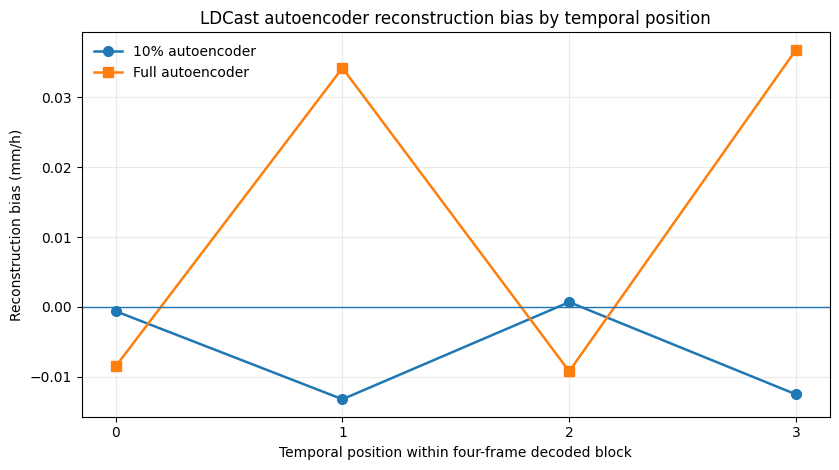

Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/ldcast_ae_bias_by_temporal_position.png


In [5]:

fig, ax = plt.subplots(figsize=(8.5, 4.8))

for split, marker in [
    ("10%", "o"),
    ("Full", "s"),
]:
    subset = diagnostic[diagnostic["Autoencoder"] == split]

    ax.plot(
        subset["Position"],
        subset["Bias"],
        marker=marker,
        linewidth=1.8,
        markersize=7,
        label=f"{split} autoencoder",
    )

ax.axhline(0.0, linewidth=1.0)

ax.set_xticks([0, 1, 2, 3])
ax.set_xlabel("Temporal position within four-frame decoded block")
ax.set_ylabel("Reconstruction bias (mm/h)")
ax.set_title("LDCast autoencoder reconstruction bias by temporal position")
ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.tight_layout()

output_path = FIG_DIR / "ldcast_ae_bias_by_temporal_position.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

## Compact combined diagnostic figure

This version is useful for a thesis appendix, presentation, or repository
README because it places MAE and bias side by side.

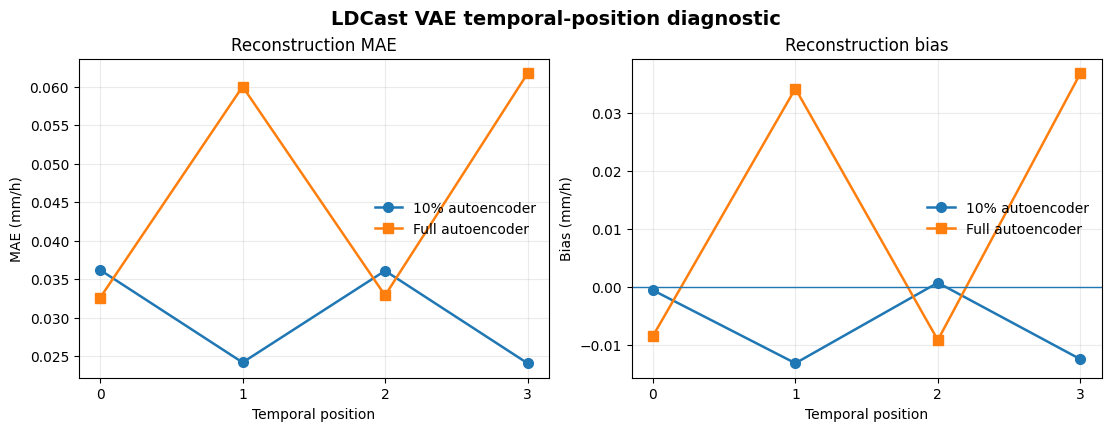

Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/test_2021_6hourly/figures_results/ldcast_ae_temporal_diagnostic.png


In [6]:

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.0, 4.2),
    constrained_layout=True,
)

for split, marker in [
    ("10%", "o"),
    ("Full", "s"),
]:
    subset = diagnostic[diagnostic["Autoencoder"] == split]

    axes[0].plot(
        subset["Position"],
        subset["MAE"],
        marker=marker,
        linewidth=1.8,
        markersize=7,
        label=f"{split} autoencoder",
    )

    axes[1].plot(
        subset["Position"],
        subset["Bias"],
        marker=marker,
        linewidth=1.8,
        markersize=7,
        label=f"{split} autoencoder",
    )

axes[0].set_title("Reconstruction MAE")
axes[0].set_ylabel("MAE (mm/h)")

axes[1].set_title("Reconstruction bias")
axes[1].set_ylabel("Bias (mm/h)")
axes[1].axhline(0.0, linewidth=1.0)

for ax in axes:
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xlabel("Temporal position")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

fig.suptitle(
    "LDCast VAE temporal-position diagnostic",
    fontsize=14,
    fontweight="bold",
)

output_path = FIG_DIR / "ldcast_ae_temporal_diagnostic.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

## Full-domain VAE reconstruction in the notebook

This section runs the selected LDCast VAE directly on one 2021 event. Only the
four input frames are reconstructed, so the diffusion generator is not loaded.

By default the final full-data VAE checkpoint (epoch 2) and the intense
convection case (`t_start = 465264`) are used. Change `AE_SPLIT` or
`AE_EVENT_T` below to inspect another configuration or event.

The figure is displayed directly in the notebook; no intermediate reconstruction
file is read or written.

In [7]:

# ============================================================
# Direct browser reconstruction setup
# ============================================================

from pathlib import Path
import os
import sys
import gc
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch

%matplotlib inline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MLCAST_DIR = Path("/data/brussel/114/vsc11442/code/mlcast-ldcast")
FULL_CONFIG = MLCAST_DIR / "src" / "new_config_data_sampled.yaml"

TIN = 4
TARGET_SIZE = 704
REGION = "belgium"

# Final VAE checkpoints used in the thesis.
AE_CKPTS = {
    "10%": MLCAST_DIR / "results/ldcast/autoenc_10pct_crop256_b32/epoch029.ckpt",
    "full": MLCAST_DIR / "results/ldcast/autoenc_full_crop256_b32/epoch002.ckpt",
}

AE_SPLIT = "full"
AE_EVENT_T = 465264

EVENT_LABELS = {
    465264: "2021-06-04 12:00:00",
    428616: "2021-01-28 06:00:00",
    473904: "2021-07-04 12:00:00",
    476568: "2021-07-13 18:00:00",
}

AE_CKPT = AE_CKPTS[AE_SPLIT]

print("Device:", DEVICE)
print("VAE split:", AE_SPLIT)
print("Checkpoint:", AE_CKPT)
print("Event:", AE_EVENT_T, EVENT_LABELS.get(AE_EVENT_T, ""))

Device: cpu
VAE split: full
Checkpoint: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/ldcast/autoenc_full_crop256_b32/epoch002.ckpt
Event: 465264 2021-06-04 12:00:00


In [8]:

# ============================================================
# Data and conversion helpers
# ============================================================

DBZ_MEAN = 30.0
DBZ_STD = 30.0
DBZ_MIN = 0.0
DBZ_MAX = 60.0
ZR_A = 200.0
ZR_B = 1.6


def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)


def rainrate_to_norm_dbz_np(rr, a=ZR_A, b=ZR_B):
    rr = np.asarray(rr, dtype=np.float32)
    norm = np.full_like(rr, np.nan, dtype=np.float32)

    valid = np.isfinite(rr)
    positive = valid & (rr > 0)

    dbz = np.zeros_like(rr, dtype=np.float32)
    dbz[positive] = 10.0 * np.log10(a * np.power(rr[positive], b))
    dbz = np.clip(dbz, DBZ_MIN, DBZ_MAX)

    norm[valid] = (dbz[valid] - DBZ_MEAN) / DBZ_STD
    return norm.astype(np.float32)


def norm_to_dbz_np(x_norm):
    x_norm = np.asarray(x_norm, dtype=np.float32)
    return x_norm * DBZ_STD + DBZ_MEAN


def dbz_to_rainrate_np(dbz):
    dbz = np.asarray(dbz, dtype=np.float32)
    rr = np.full_like(dbz, np.nan, dtype=np.float32)

    valid = np.isfinite(dbz)
    dbz_valid = np.clip(dbz[valid], DBZ_MIN, DBZ_MAX)

    z = 10.0 ** (dbz_valid / 10.0)
    rr[valid] = (z / ZR_A) ** (1.0 / ZR_B)

    return rr


def to_rainrate_np(x_norm):
    return dbz_to_rainrate_np(norm_to_dbz_np(x_norm))


def pad_last_two_dims_to_square(arr, target_size=TARGET_SIZE, fill_value=np.nan):
    arr = np.asarray(arr)
    h, w = arr.shape[-2:]

    if h > target_size or w > target_size:
        raise ValueError(
            f"Input domain {h}x{w} is larger than target "
            f"{target_size}x{target_size}"
        )

    pad_h = target_size - h
    pad_w = target_size - w

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    pad_spec = [(0, 0)] * arr.ndim
    pad_spec[-2] = (pad_top, pad_bottom)
    pad_spec[-1] = (pad_left, pad_right)

    return np.pad(
        arr,
        pad_spec,
        mode="constant",
        constant_values=fill_value,
    )


def radar_source_from_config(config_path=FULL_CONFIG, region=REGION):
    scripts_dir = MLCAST_DIR / "scripts"

    if str(scripts_dir) not in sys.path:
        sys.path.insert(0, str(scripts_dir))

    try:
        from Minh_read_mlcast_yaml import load_radar_cfg
        cfg = load_radar_cfg(str(config_path), region)
        return cfg["zarr_path"], cfg["var_name"]
    except Exception:
        raw = load_yaml(config_path)
        radar = raw[region]["radar"]

        zarr_path = (
            radar.get("zarr_path")
            or radar.get("path")
            or radar.get("data_path")
            or radar.get("filename")
        )

        var_name = (
            radar.get("var_name")
            or radar.get("variable_name")
            or radar.get("standard_name")
            or "precip_intensity_EDK"
        )

        if zarr_path is None:
            raise KeyError(f"Could not find RADCLIM Zarr path in {config_path}")

        return zarr_path, var_name


def load_ae_event(t_start=AE_EVENT_T):
    import xarray as xr

    zarr_path, var_name = radar_source_from_config()

    ds = xr.open_zarr(zarr_path)

    rr = (
        ds[var_name]
        .isel(time=slice(int(t_start), int(t_start) + TIN))
        .values
        .astype(np.float32)
    )

    rr = pad_last_two_dims_to_square(
        rr,
        target_size=TARGET_SIZE,
        fill_value=np.nan,
    )

    norm = rainrate_to_norm_dbz_np(rr)
    valid_mask = np.isfinite(norm)

    # The trained VAE receives -1 for invalid/dry padded pixels.
    model_input = np.where(
        valid_mask,
        norm,
        -1.0,
    ).astype(np.float32)

    return {
        "rr": rr,
        "norm": norm,
        "model_input": model_input,
        "valid_mask": valid_mask,
    }


# Same precipitation levels used in the qualitative figures.
PRECIP_LEVELS = [
    0.0, 0.1, 0.25, 0.4, 0.63, 1.0, 1.6, 2.5,
    4.0, 6.3, 10.0, 16.0, 25.0, 40.0, 63.0, 100.0,
]

PRECIP_CMAP = mcolors.ListedColormap(
    [
        "white", "cyan", "deepskyblue", "dodgerblue", "blue",
        "chartreuse", "limegreen", "green", "darkgreen",
        "yellow", "gold", "orange", "red", "magenta", "darkmagenta",
    ]
)
PRECIP_CMAP.set_bad(color=(1, 1, 1, 0))
PRECIP_NORM = mcolors.BoundaryNorm(
    PRECIP_LEVELS,
    PRECIP_CMAP.N,
    clip=True,
)

In [9]:

# ============================================================
# Load the selected VAE checkpoint and reconstruct the event
# ============================================================

def switch_to_ldcast_source():
    ldcast_src = MLCAST_DIR / "src"
    ldcast_scripts = MLCAST_DIR / "scripts"

    for path in [ldcast_src, ldcast_scripts]:
        path = str(path)
        if path not in sys.path:
            sys.path.insert(0, path)

    # Ensure that imports resolve to this local mlcast-ldcast tree.
    for module_name in list(sys.modules):
        if module_name == "mlcast" or module_name.startswith("mlcast."):
            del sys.modules[module_name]

    return ldcast_src


def strip_prefix_if_all(state_dict, prefix):
    if state_dict and all(k.startswith(prefix) for k in state_dict):
        return {
            k[len(prefix):]: value
            for k, value in state_dict.items()
        }
    return state_dict


def load_state_dict_any(path):
    checkpoint = torch.load(
        path,
        map_location="cpu",
        weights_only=False,
    )

    state = (
        checkpoint["state_dict"]
        if isinstance(checkpoint, dict) and "state_dict" in checkpoint
        else checkpoint
    )

    for prefix in ("module.", "model."):
        state = strip_prefix_if_all(state, prefix)

    return state


def build_autoencoder(checkpoint_path):
    ldcast_src = switch_to_ldcast_source()
    print("Using source:", ldcast_src)

    from mlcast.models.ldcast.autoenc.autoenc import (
        Autoencoder,
        AutoencoderKLNet,
        AutoencoderLoss,
    )
    from mlcast.models.ldcast.autoenc.encoder import (
        SimpleConvEncoder,
        SimpleConvDecoder,
    )

    encoder = SimpleConvEncoder()
    decoder = SimpleConvDecoder()

    network = AutoencoderKLNet(
        encoder=encoder,
        decoder=decoder,
    )

    loss = AutoencoderLoss(
        kl_weight=0.01,
    )

    autoencoder = Autoencoder(
        net=network,
        loss=loss,
        antialiaser=None,
        optimizer_class=torch.optim.Adam,
        optimizer_kwargs={"lr": 1e-4},
        lr_scheduler_config=None,
    )

    state = load_state_dict_any(checkpoint_path)
    autoencoder.load_state_dict(state, strict=True)

    return autoencoder


def ae_decode(autoencoder, latent):
    if hasattr(autoencoder, "decode"):
        return autoencoder.decode(latent)

    if hasattr(autoencoder, "net") and hasattr(autoencoder.net, "decode"):
        return autoencoder.net.decode(latent)

    raise AttributeError("Could not find the VAE decode method.")


@torch.inference_mode()
def reconstruct_event(autoencoder, event):
    # LDCast VAE layout: [batch, channel, time, y, x]
    x = torch.from_numpy(
        event["model_input"]
    ).unsqueeze(0).unsqueeze(0).float().to(DEVICE)

    with torch.autocast(
        device_type="cuda",
        dtype=torch.bfloat16,
        enabled=torch.cuda.is_available(),
    ):
        latent = autoencoder.encode(x)
        reconstruction = ae_decode(autoencoder, latent)

    reconstruction = (
        reconstruction.detach()
        .float()
        .cpu()
        .numpy()[0, 0]
        .astype(np.float32)
    )

    reconstruction = np.where(
        event["valid_mask"],
        reconstruction,
        np.nan,
    )

    return reconstruction, latent, x


if not AE_CKPT.exists():
    raise FileNotFoundError(f"Missing VAE checkpoint: {AE_CKPT}")

event = load_ae_event(AE_EVENT_T)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

autoencoder = build_autoencoder(AE_CKPT).to(DEVICE)
autoencoder.eval()

rec_norm, latent, ae_input = reconstruct_event(
    autoencoder,
    event,
)

print("VAE input:         ", tuple(ae_input.shape))
print("Latent tensor:     ", tuple(latent.shape))
print("VAE reconstruction:", rec_norm.shape)

Using source: /data/brussel/114/vsc11442/code/mlcast-ldcast/src


/data/brussel/114/vsc11442/venvs/mlcast_ldcast/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


VAE input:          (1, 1, 4, 704, 704)
Latent tensor:      (1, 32, 1, 176, 176)
VAE reconstruction: (4, 704, 704)


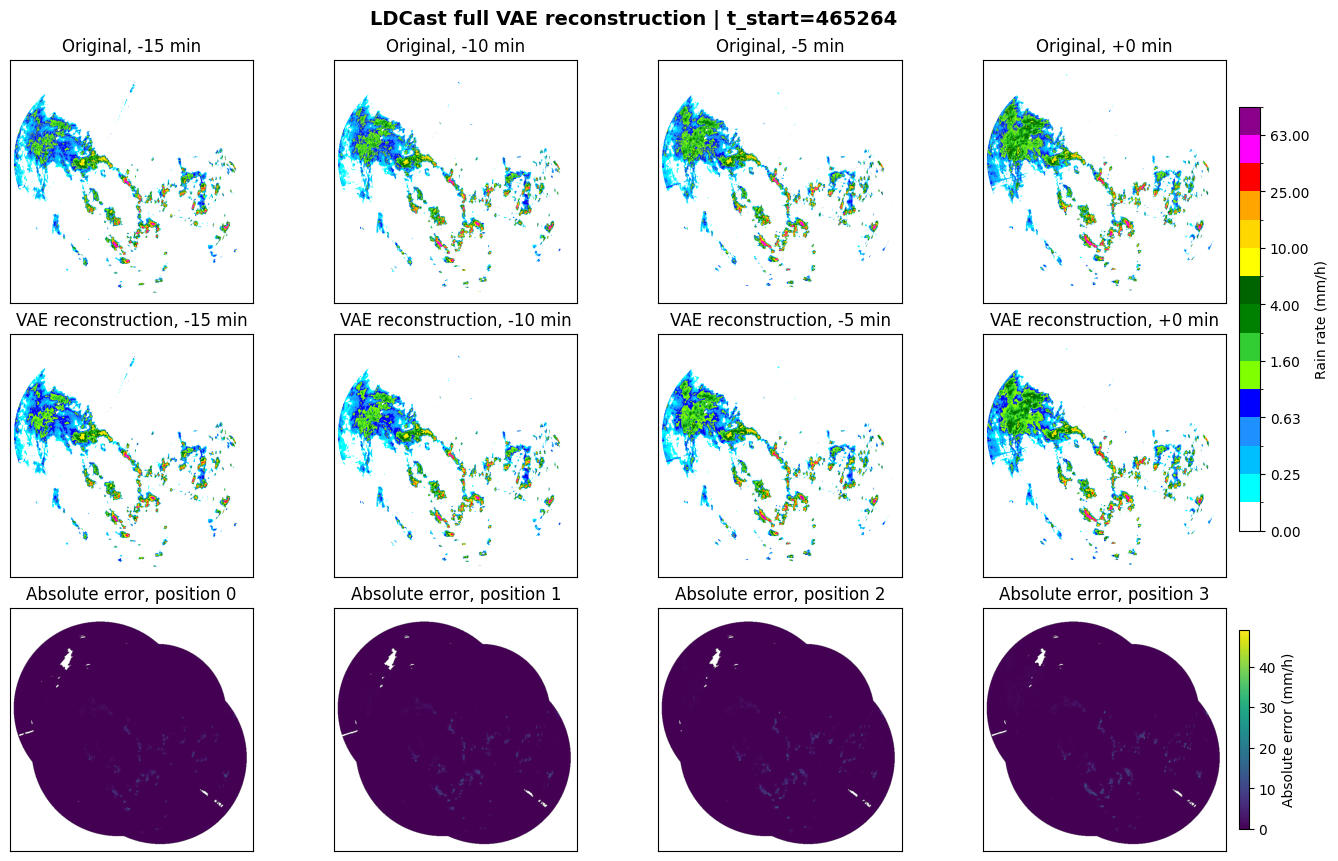

,temporal_position,relative_time_min,bias_mm_h,mae_mm_h
0,0,-15,-0.048263,0.120551
1,1,-10,-0.056456,0.124626
2,2,-5,-0.052678,0.135993
3,3,0,-0.066395,0.150386


183

In [10]:

# ============================================================
# Plot original, VAE reconstruction, and reconstruction error
# directly in the notebook
# ============================================================

orig_rr = to_rainrate_np(event["norm"])
rec_rr = to_rainrate_np(rec_norm)
abs_error_rr = np.abs(rec_rr - orig_rr)

relative_times = [-15, -10, -5, 0]

fig, axes = plt.subplots(
    3,
    TIN,
    figsize=(14.0, 8.5),
    constrained_layout=True,
)

precip_image = None
error_image = None

for frame_idx in range(TIN):

    # Original
    original_plot = np.ma.masked_where(
        (~np.isfinite(orig_rr[frame_idx]))
        | (orig_rr[frame_idx] < 0.1),
        orig_rr[frame_idx],
    )

    precip_image = axes[0, frame_idx].imshow(
        original_plot,
        origin="upper",
        cmap=PRECIP_CMAP,
        norm=PRECIP_NORM,
    )

    axes[0, frame_idx].set_title(
        f"Original, {relative_times[frame_idx]:+d} min"
    )

    # Reconstruction
    reconstruction_plot = np.ma.masked_where(
        (~np.isfinite(rec_rr[frame_idx]))
        | (rec_rr[frame_idx] < 0.1),
        rec_rr[frame_idx],
    )

    axes[1, frame_idx].imshow(
        reconstruction_plot,
        origin="upper",
        cmap=PRECIP_CMAP,
        norm=PRECIP_NORM,
    )

    axes[1, frame_idx].set_title(
        f"VAE reconstruction, {relative_times[frame_idx]:+d} min"
    )

    # Absolute error
    error_image = axes[2, frame_idx].imshow(
        abs_error_rr[frame_idx],
        origin="upper",
    )

    axes[2, frame_idx].set_title(
        f"Absolute error, position {frame_idx}"
    )

    for row in range(3):
        axes[row, frame_idx].set_xticks([])
        axes[row, frame_idx].set_yticks([])

fig.colorbar(
    precip_image,
    ax=axes[:2, :],
    shrink=0.82,
    pad=0.01,
    label="Rain rate (mm/h)",
)

fig.colorbar(
    error_image,
    ax=axes[2, :],
    shrink=0.82,
    pad=0.01,
    label="Absolute error (mm/h)",
)

fig.suptitle(
    f"LDCast {AE_SPLIT} VAE reconstruction | "
    f"t_start={AE_EVENT_T}",
    fontsize=14,
    fontweight="bold",
)

plt.show()


# Per-frame diagnostics for this one visual example.
example_rows = []

for frame_idx in range(TIN):
    valid = (
        np.isfinite(orig_rr[frame_idx])
        & np.isfinite(rec_rr[frame_idx])
    )

    error = rec_rr[frame_idx][valid] - orig_rr[frame_idx][valid]

    example_rows.append(
        {
            "temporal_position": frame_idx,
            "relative_time_min": relative_times[frame_idx],
            "bias_mm_h": float(np.mean(error)),
            "mae_mm_h": float(np.mean(np.abs(error))),
        }
    )

example_metrics = pd.DataFrame(example_rows)
display(example_metrics)


# Free GPU memory after the visual diagnostic.
del ae_input, latent, autoencoder

if torch.cuda.is_available():
    torch.cuda.empty_cache()

gc.collect()